# Probabilistic MeteoSwiss wind forecasts for the Swiss network

This notebook maps MeteoSwiss local wind forecasts to a MATPOWER-style
transmission network:

1. read `bus.csv` (`bus_i`, `lat`, `lon`) and `branch.csv` (`fbus`, `tbus`);
2. retain active non-transformer branches;
3. create weather targets at buses and 20 geodesic samples per branch;
4. match each target to the nearest MeteoSwiss forecast point;
5. retrieve mean wind, gusts and Q10/Q90 forecasts;
6. retain the next 24 hourly forecast intervals by default;
7. construct branch-level quantile screening indicators; and
8. visualize spatially varying segment colours on the official Swiss boundary.

The local forecast product supplies a main non-quantile forecast and pointwise
Q10/Q90 quantiles. These are **not** ensemble-member scenarios and do not
define a full probability density function.

The workflow uses regular CSV and WMS downloads. It does **not** require
GRIB, ecCodes, Docker, WSL, GeoPandas or Cartopy.

Required packages:

```powershell
python -m pip install numpy pandas matplotlib
```

Run the notebook from anywhere inside the PROPER repository. The project root
is detected from `data/powersystems/Swiss2025/network_csvs`.


```powershell
python probabilistic_models/weather/meteoswiss_wind_forecast.py --project-root . --samples-per-line 20  --horizon-hours 24  --line-colour-variable wind_speed_kmh --colour-map plasma


python probabilistic_models/weather/meteoswiss_wind_forecast.py --project-root . --samples-per-line 40  --horizon-hours 24  --line-colour-variable wind_speed_q90_kmh --colour-map plasma



```

## Imports and public constants


In [1]:
from __future__ import annotations

import argparse
import hashlib
import json
import os
import re
import tempfile
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode, urlparse
from urllib.request import Request, urlopen
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize


STAC_BASE_URL = "https://data.geo.admin.ch/api/stac/v1"
COLLECTION_ID = "ch.meteoschweiz.ogd-local-forecasting"
COLLECTION_ROOT = f"https://data.geo.admin.ch/{COLLECTION_ID}"
POINT_METADATA_URL = (
    f"{COLLECTION_ROOT}/ogd-local-forecasting_meta_point.csv"
)
WMS_BASE_URL = "https://wms.geo.admin.ch/"
BOUNDARY_LAYER = "ch.swisstopo.swissboundaries3d-land-flaeche.fill"
LOCAL_TZ = ZoneInfo("Europe/Zurich")

# Longitude minimum, latitude minimum, longitude maximum, latitude maximum.
SWITZERLAND_BBOX = (5.70, 45.70, 10.70, 47.90)

WIND_PARAMETERS: dict[str, str] = {
    "dkl010h0": "wind_direction_deg_from",
    "fu3010h0": "wind_speed_kmh",
    "fu3010h1": "wind_gust_kmh",
    "fu3q10h0": "wind_speed_q10_kmh",
    "fu3q10h1": "wind_gust_q10_kmh",
    "fu3q90h0": "wind_speed_q90_kmh",
    "fu3q90h1": "wind_gust_q90_kmh",
}

LINE_COLOUR_VARIABLES: dict[str, str] = {
    "wind_speed_q10_ms": "Pointwise Q10 hourly-mean wind speed [m/s]",
    "wind_speed_ms": "Main (non-quantile) hourly-mean wind speed [m/s]",
    "wind_speed_q90_ms": "Pointwise Q90 hourly-mean wind speed [m/s]",
    "wind_gust_q10_ms": "Pointwise Q10 hourly-maximum gust [m/s]",
    "wind_gust_ms": "Main (non-quantile) hourly-maximum gust [m/s]",
    "wind_gust_q90_ms": "Pointwise Q90 hourly-maximum gust [m/s]",
}

DEFAULT_SAMPLES_PER_LINE = 50
DEFAULT_HORIZON_HOURS = 48
DEFAULT_LINE_COLOUR_VARIABLE = "wind_gust_q90_ms"
DEFAULT_COLOUR_MAP = "Blues"

BUS_ID = "bus_i"
LINE_ID = "line_id"
FROM_BUS = "fbus"
TO_BUS = "tbus"

USER_AGENT = "PROPER-MeteoSwiss-wind/1.0"


## HTTP and cache utilities


In [2]:
def _request(
    url: str,
    *,
    timeout: float = 120.0,
    attempts: int = 3,
    allow_not_found: bool = False,
) -> bytes | None:
    """Return URL contents with bounded retry handling."""

    last_error: Exception | None = None
    request = Request(url, headers={"User-Agent": USER_AGENT})

    for attempt in range(1, attempts + 1):
        try:
            with urlopen(request, timeout=timeout) as response:
                return response.read()
        except HTTPError as error:
            if error.code == 404 and allow_not_found:
                return None
            last_error = error
            if error.code < 500 or attempt == attempts:
                raise
        except (URLError, TimeoutError, OSError) as error:
            last_error = error
            if attempt == attempts:
                raise

        time.sleep(min(2 ** (attempt - 1), 4))

    raise RuntimeError(f"Could not retrieve {url}") from last_error


def fetch_json(
    url: str,
    *,
    timeout: float = 60.0,
    allow_not_found: bool = False,
) -> dict[str, Any] | None:
    payload = _request(
        url,
        timeout=timeout,
        allow_not_found=allow_not_found,
    )
    if payload is None:
        return None
    return json.loads(payload.decode("utf-8"))


def download_cached(
    url: str,
    destination: Path,
    *,
    refresh: bool = False,
    timeout: float = 240.0,
    attempts: int = 3,
) -> Path:
    """Download atomically and reuse a non-empty cached file."""

    destination = Path(destination)
    if destination.is_file() and destination.stat().st_size > 0 and not refresh:
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    last_error: Exception | None = None

    for attempt in range(1, attempts + 1):
        file_descriptor, temporary_name = tempfile.mkstemp(
            prefix=f"{destination.name}.",
            suffix=".part",
            dir=destination.parent,
        )
        os.close(file_descriptor)
        temporary_path = Path(temporary_name)

        try:
            request = Request(url, headers={"User-Agent": USER_AGENT})
            digest = hashlib.sha256()
            byte_count = 0

            with urlopen(request, timeout=timeout) as response:
                expected_size_text = response.headers.get("Content-Length")
                expected_size = (
                    int(expected_size_text) if expected_size_text else None
                )
                expected_digest = response.headers.get("x-amz-meta-sha256")

                with temporary_path.open("wb") as output_file:
                    while True:
                        block = response.read(1024 * 1024)
                        if not block:
                            break
                        output_file.write(block)
                        digest.update(block)
                        byte_count += len(block)

            if expected_size is not None and byte_count != expected_size:
                raise IOError(
                    f"Incomplete download for {url}: received {byte_count} "
                    f"bytes, expected {expected_size}."
                )

            if expected_digest and digest.hexdigest() != expected_digest:
                raise IOError(f"SHA-256 mismatch for {url}")

            os.replace(temporary_path, destination)
            return destination

        except (HTTPError, URLError, TimeoutError, OSError) as error:
            last_error = error
            temporary_path.unlink(missing_ok=True)
            if attempt == attempts:
                raise
            time.sleep(min(2 ** (attempt - 1), 4))

    raise RuntimeError(f"Could not download {url}") from last_error


def discover_project_root(
    search_starts: Sequence[Path] | None = None,
) -> Path:
    """Find a PROPER root containing the expected Swiss2025 network files."""

    if search_starts is None:
        search_starts = [Path.cwd(), Path(__file__).resolve().parent]

    visited: set[Path] = set()
    for start in search_starts:
        resolved_start = Path(start).expanduser().resolve()
        for candidate in (resolved_start, *resolved_start.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            network_directory = (
                candidate
                / "data"
                / "powersystems"
                / "Swiss2025"
                / "network_csvs"
            )
            if (
                (network_directory / "bus.csv").is_file()
                and (network_directory / "branch.csv").is_file()
            ):
                return candidate

    raise FileNotFoundError(
        "Could not locate data/powersystems/Swiss2025/network_csvs. "
        "Run from inside the PROPER repository or pass --bus-file and "
        "--branch-file explicitly."
    )


## Network validation and geometry


In [3]:
def _require_columns(
    dataframe: pd.DataFrame,
    required: Iterable[str],
    table_name: str,
) -> None:
    missing = set(required) - set(dataframe.columns)
    if missing:
        raise ValueError(
            f"{table_name} is missing columns: {sorted(missing)}"
        )


def normalize_matpower_bus_ids(
    values: pd.Series,
    column_name: str,
) -> pd.Series:
    """Convert validated MATPOWER bus identifiers to integers."""

    numeric = pd.to_numeric(values, errors="coerce")
    if numeric.isna().any():
        invalid = values.loc[numeric.isna()].head(10).tolist()
        raise ValueError(
            f"{column_name} contains missing or invalid IDs: {invalid}"
        )
    if not np.allclose(numeric, np.round(numeric)):
        raise ValueError(f"{column_name} contains non-integer bus IDs")
    return numeric.round().astype("int64")


def haversine_km(
    lat1: Any,
    lon1: Any,
    lat2: Any,
    lon2: Any,
) -> np.ndarray:
    """Great-circle distance in kilometres."""

    earth_radius_km = 6371.0088
    phi1 = np.radians(np.asarray(lat1, dtype=float))
    phi2 = np.radians(np.asarray(lat2, dtype=float))
    delta_phi = phi2 - phi1
    delta_lambda = np.radians(
        np.asarray(lon2, dtype=float) - np.asarray(lon1, dtype=float)
    )
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(
        np.sqrt(np.clip(a, 0, 1))
    )


def geodesic_midpoint(
    lat1: Any,
    lon1: Any,
    lat2: Any,
    lon2: Any,
) -> tuple[np.ndarray, np.ndarray]:
    """Great-circle midpoint between WGS84 endpoint pairs."""

    phi1 = np.radians(np.asarray(lat1, dtype=float))
    phi2 = np.radians(np.asarray(lat2, dtype=float))
    lambda1 = np.radians(np.asarray(lon1, dtype=float))
    lambda2 = np.radians(np.asarray(lon2, dtype=float))
    delta_lambda = lambda2 - lambda1

    bx = np.cos(phi2) * np.cos(delta_lambda)
    by = np.cos(phi2) * np.sin(delta_lambda)
    phi_mid = np.arctan2(
        np.sin(phi1) + np.sin(phi2),
        np.sqrt((np.cos(phi1) + bx) ** 2 + by**2),
    )
    lambda_mid = lambda1 + np.arctan2(by, np.cos(phi1) + bx)

    latitude = np.degrees(phi_mid)
    longitude = (np.degrees(lambda_mid) + 540) % 360 - 180
    return latitude, longitude


def geodesic_sample_points(
    line_geometry: pd.DataFrame,
    samples_per_line: int,
) -> pd.DataFrame:
    """Create equally spaced great-circle samples, including both endpoints."""

    if isinstance(samples_per_line, bool) or int(samples_per_line) < 2:
        raise ValueError("samples_per_line must be an integer of at least 2")
    samples_per_line = int(samples_per_line)

    fractions = np.linspace(0.0, 1.0, samples_per_line)
    lat1 = np.radians(line_geometry["from_lat"].to_numpy(float))
    lon1 = np.radians(line_geometry["from_lon"].to_numpy(float))
    lat2 = np.radians(line_geometry["to_lat"].to_numpy(float))
    lon2 = np.radians(line_geometry["to_lon"].to_numpy(float))

    start_vectors = np.column_stack(
        (
            np.cos(lat1) * np.cos(lon1),
            np.cos(lat1) * np.sin(lon1),
            np.sin(lat1),
        )
    )
    end_vectors = np.column_stack(
        (
            np.cos(lat2) * np.cos(lon2),
            np.cos(lat2) * np.sin(lon2),
            np.sin(lat2),
        )
    )
    angular_distance = np.arccos(
        np.clip(np.sum(start_vectors * end_vectors, axis=1), -1.0, 1.0)
    )

    sample_vectors = np.empty(
        (len(line_geometry), samples_per_line, 3), dtype=float
    )
    distinct_endpoints = angular_distance > 1e-12

    if distinct_endpoints.any():
        omega = angular_distance[distinct_endpoints, None]
        denominator = np.sin(omega)
        start_weight = np.sin((1.0 - fractions[None, :]) * omega) / denominator
        end_weight = np.sin(fractions[None, :] * omega) / denominator
        sample_vectors[distinct_endpoints] = (
            start_weight[:, :, None]
            * start_vectors[distinct_endpoints, None, :]
            + end_weight[:, :, None]
            * end_vectors[distinct_endpoints, None, :]
        )

    if (~distinct_endpoints).any():
        sample_vectors[~distinct_endpoints] = start_vectors[
            ~distinct_endpoints, None, :
        ]

    sample_vectors /= np.linalg.norm(sample_vectors, axis=2, keepdims=True)
    sample_latitudes = np.degrees(np.arcsin(sample_vectors[:, :, 2]))
    sample_longitudes = np.degrees(
        np.arctan2(sample_vectors[:, :, 1], sample_vectors[:, :, 0])
    )

    line_ids = np.repeat(
        line_geometry[LINE_ID].astype(str).to_numpy(), samples_per_line
    )
    sample_indices = np.tile(np.arange(samples_per_line), len(line_geometry))
    sample_fractions = np.tile(fractions, len(line_geometry))
    width = max(2, len(str(samples_per_line - 1)))
    target_ids = [
        f"line:{line_id}:sample_{sample_index:0{width}d}"
        for line_id, sample_index in zip(line_ids, sample_indices)
    ]
    sample_roles = np.full(len(target_ids), "interior", dtype=object)
    sample_roles[sample_indices == 0] = "from_bus"
    sample_roles[sample_indices == samples_per_line - 1] = "to_bus"

    return pd.DataFrame(
        {
            LINE_ID: line_ids,
            "target_id": target_ids,
            "target_type": "line_sample",
            "sample_index": sample_indices,
            "sample_fraction": sample_fractions,
            "sample_role": sample_roles,
            "lat": sample_latitudes.reshape(-1),
            "lon": sample_longitudes.reshape(-1),
        }
    )


def initial_bearing_deg(
    lat1: Any,
    lon1: Any,
    lat2: Any,
    lon2: Any,
) -> np.ndarray:
    """Initial great-circle bearing, clockwise from north."""

    phi1 = np.radians(np.asarray(lat1, dtype=float))
    phi2 = np.radians(np.asarray(lat2, dtype=float))
    delta_lambda = np.radians(
        np.asarray(lon2, dtype=float) - np.asarray(lon1, dtype=float)
    )
    y = np.sin(delta_lambda) * np.cos(phi2)
    x = (
        np.cos(phi1) * np.sin(phi2)
        - np.sin(phi1) * np.cos(phi2) * np.cos(delta_lambda)
    )
    return (np.degrees(np.arctan2(y, x)) + 360) % 360


def prepare_network_targets(
    bus_file: Path,
    branch_file: Path,
    *,
    samples_per_line: int = DEFAULT_SAMPLES_PER_LINE,
    active_branches_only: bool = True,
    exclude_transformers: bool = True,
) -> dict[str, pd.DataFrame]:
    """Read the network and construct bus and branch-sample targets."""

    bus_file = Path(bus_file)
    branch_file = Path(branch_file)
    buses = pd.read_csv(bus_file)
    branches_all = pd.read_csv(branch_file).reset_index(drop=True)

    _require_columns(buses, [BUS_ID, "lat", "lon"], bus_file.name)
    _require_columns(
        branches_all,
        [FROM_BUS, TO_BUS, "status", "ratio"],
        branch_file.name,
    )

    buses[BUS_ID] = normalize_matpower_bus_ids(buses[BUS_ID], BUS_ID)
    for column in (FROM_BUS, TO_BUS):
        branches_all[column] = normalize_matpower_bus_ids(
            branches_all[column], column
        )

    if buses[BUS_ID].duplicated().any():
        duplicates = (
            buses.loc[buses[BUS_ID].duplicated(keep=False), BUS_ID]
            .unique()
            .tolist()
        )
        raise ValueError(f"{BUS_ID} must be unique: {duplicates[:10]}")

    buses[["lat", "lon"]] = buses[["lat", "lon"]].apply(
        pd.to_numeric, errors="coerce"
    )
    invalid_coordinates = (
        buses["lat"].isna()
        | buses["lon"].isna()
        | ~buses["lat"].between(-90, 90)
        | ~buses["lon"].between(-180, 180)
    )
    if invalid_coordinates.any():
        invalid = buses.loc[
            invalid_coordinates, [BUS_ID, "lat", "lon"]
        ].head(10)
        raise ValueError(f"Invalid bus coordinates:\n{invalid}")

    branches_all.insert(
        0, "source_row", np.arange(len(branches_all), dtype=int)
    )
    if LINE_ID not in branches_all.columns:
        branches_all[LINE_ID] = branches_all["source_row"].map(
            lambda row: f"branch_{row:06d}"
        )
    if branches_all[LINE_ID].isna().any() or branches_all[LINE_ID].duplicated().any():
        raise ValueError("line_id must be complete and unique")
    branches_all[LINE_ID] = branches_all[LINE_ID].astype(str)

    branch_mask = pd.Series(True, index=branches_all.index)
    if active_branches_only:
        branch_status = pd.to_numeric(
            branches_all["status"], errors="coerce"
        )
        branch_mask &= branch_status.eq(1)
    if exclude_transformers:
        # MATPOWER convention: a zero ratio denotes a non-transformer branch.
        tap_ratio = pd.to_numeric(
            branches_all["ratio"], errors="coerce"
        ).fillna(0.0)
        branch_mask &= np.isclose(tap_ratio, 0.0)

    branches = branches_all.loc[branch_mask].copy()
    available_buses = set(buses[BUS_ID])
    referenced_buses = set(branches[FROM_BUS]) | set(branches[TO_BUS])
    unknown_buses = sorted(referenced_buses - available_buses)
    if unknown_buses:
        raise ValueError(
            "Branches reference IDs absent from bus.csv: "
            f"{unknown_buses[:10]}"
        )

    bus_coordinates = buses.set_index(BUS_ID)[["lat", "lon"]]
    line_geometry = branches.copy()
    line_geometry["from_lat"] = line_geometry[FROM_BUS].map(
        bus_coordinates["lat"]
    )
    line_geometry["from_lon"] = line_geometry[FROM_BUS].map(
        bus_coordinates["lon"]
    )
    line_geometry["to_lat"] = line_geometry[TO_BUS].map(
        bus_coordinates["lat"]
    )
    line_geometry["to_lon"] = line_geometry[TO_BUS].map(
        bus_coordinates["lon"]
    )
    (
        line_geometry["mid_lat"],
        line_geometry["mid_lon"],
    ) = geodesic_midpoint(
        line_geometry["from_lat"],
        line_geometry["from_lon"],
        line_geometry["to_lat"],
        line_geometry["to_lon"],
    )
    line_geometry["endpoint_distance_km"] = haversine_km(
        line_geometry["from_lat"],
        line_geometry["from_lon"],
        line_geometry["to_lat"],
        line_geometry["to_lon"],
    )
    line_geometry["line_bearing_deg"] = initial_bearing_deg(
        line_geometry["from_lat"],
        line_geometry["from_lon"],
        line_geometry["to_lat"],
        line_geometry["to_lon"],
    )
    if "length" in line_geometry.columns:
        line_geometry["reported_length"] = pd.to_numeric(
            line_geometry["length"], errors="coerce"
        )

    bus_targets = buses[[BUS_ID, "lat", "lon"]].copy()
    bus_targets[BUS_ID] = bus_targets[BUS_ID].astype("Int64")
    bus_targets["target_id"] = "bus:" + bus_targets[BUS_ID].astype(str)
    bus_targets["target_type"] = "bus"
    bus_targets[LINE_ID] = pd.Series(
        pd.NA, index=bus_targets.index, dtype="string"
    )

    line_samples = geodesic_sample_points(
        line_geometry,
        samples_per_line=samples_per_line,
    )
    line_samples[LINE_ID] = line_samples[LINE_ID].astype("string")
    line_samples[BUS_ID] = pd.Series(
        pd.NA, index=line_samples.index, dtype="Int64"
    )
    line_samples["sample_index"] = line_samples["sample_index"].astype(
        "Int64"
    )
    line_samples["sample_fraction"] = line_samples[
        "sample_fraction"
    ].astype("Float64")
    line_samples["sample_role"] = line_samples["sample_role"].astype(
        "string"
    )

    bus_targets["sample_index"] = pd.Series(
        pd.NA, index=bus_targets.index, dtype="Int64"
    )
    bus_targets["sample_fraction"] = pd.Series(
        pd.NA, index=bus_targets.index, dtype="Float64"
    )
    bus_targets["sample_role"] = pd.Series(
        pd.NA, index=bus_targets.index, dtype="string"
    )

    target_columns = [
        "target_id",
        "target_type",
        BUS_ID,
        LINE_ID,
        "sample_index",
        "sample_fraction",
        "sample_role",
        "lat",
        "lon",
    ]
    targets = pd.concat(
        [bus_targets[target_columns], line_samples[target_columns]],
        ignore_index=True,
    )

    return {
        "buses": buses,
        "branches_all": branches_all,
        "branches": branches,
        "line_geometry": line_geometry,
        "line_samples": line_samples,
        "targets": targets,
    }


## MeteoSwiss point metadata and spatial matching


In [4]:
def load_meteoswiss_points(
    data_directory: Path,
    *,
    refresh: bool = False,
) -> pd.DataFrame:
    """Download and validate the MeteoSwiss point catalogue."""

    metadata_path = (
        Path(data_directory)
        / "metadata"
        / "ogd-local-forecasting_meta_point.csv"
    )
    download_cached(
        POINT_METADATA_URL,
        metadata_path,
        refresh=refresh,
    )
    points = pd.read_csv(metadata_path, sep=";", encoding="latin-1")

    required_columns = [
        "point_id",
        "point_type_id",
        "point_name",
        "point_height_masl",
        "point_coordinates_wgs84_lat",
        "point_coordinates_wgs84_lon",
    ]
    _require_columns(points, required_columns, metadata_path.name)

    for column in (
        "point_id",
        "point_type_id",
        "point_height_masl",
        "point_coordinates_wgs84_lat",
        "point_coordinates_wgs84_lon",
    ):
        points[column] = pd.to_numeric(points[column], errors="coerce")

    points = points.dropna(
        subset=[
            "point_id",
            "point_type_id",
            "point_coordinates_wgs84_lat",
            "point_coordinates_wgs84_lon",
        ]
    ).copy()
    points[["point_id", "point_type_id"]] = points[
        ["point_id", "point_type_id"]
    ].astype("int64")

    point_keys = ["point_type_id", "point_id"]
    duplicated_keys = points.duplicated(point_keys, keep=False)
    if duplicated_keys.any():
        comparison_columns = [
            "point_name",
            "point_height_masl",
            "point_coordinates_wgs84_lat",
            "point_coordinates_wgs84_lon",
        ]
        conflicting = (
            points.loc[duplicated_keys]
            .groupby(point_keys, dropna=False)[comparison_columns]
            .nunique(dropna=False)
            .gt(1)
            .any(axis=1)
        )
        if conflicting.any():
            raise ValueError(
                "MeteoSwiss point metadata contains conflicting rows for "
                f"composite keys: {conflicting[conflicting].index.tolist()[:10]}"
            )
        # The live catalogue occasionally contains byte-for-byte duplicate
        # station rows. They do not represent distinct forecast points.
        points = points.drop_duplicates(point_keys, keep="first").copy()
    return points


def attach_nearest_poi(
    targets: pd.DataFrame,
    points: pd.DataFrame,
    *,
    max_distance_km: float = 10.0,
    allowed_point_types: Iterable[int] | None = None,
) -> pd.DataFrame:
    """Attach the horizontally nearest MeteoSwiss forecast point.

    The search is performed in bounded vectorized batches. This remains exact
    on a spherical Earth while avoiding one Python loop over roughly
    ``number_of_lines * samples_per_line`` targets.
    """

    _require_columns(targets, ["target_id", "lat", "lon"], "targets")
    if targets["target_id"].duplicated().any():
        raise ValueError("target_id must be unique")

    candidates = points.copy()
    if allowed_point_types is not None:
        allowed = {int(point_type) for point_type in allowed_point_types}
        candidates = candidates.loc[
            candidates["point_type_id"].isin(allowed)
        ].copy()
    if candidates.empty:
        raise ValueError("No eligible MeteoSwiss forecast points remain")

    target_coordinates = targets[["lat", "lon"]].apply(
        pd.to_numeric, errors="coerce"
    )
    if target_coordinates.isna().any().any():
        raise ValueError("Targets contain invalid latitude or longitude")

    def unit_vectors(latitude: np.ndarray, longitude: np.ndarray) -> np.ndarray:
        latitude_rad = np.radians(latitude)
        longitude_rad = np.radians(longitude)
        return np.column_stack(
            (
                np.cos(latitude_rad) * np.cos(longitude_rad),
                np.cos(latitude_rad) * np.sin(longitude_rad),
                np.sin(latitude_rad),
            )
        )

    candidate_vectors = unit_vectors(
        candidates["point_coordinates_wgs84_lat"].to_numpy(float),
        candidates["point_coordinates_wgs84_lon"].to_numpy(float),
    )
    target_vectors = unit_vectors(
        target_coordinates["lat"].to_numpy(float),
        target_coordinates["lon"].to_numpy(float),
    )

    nearest_positions = np.empty(len(targets), dtype=int)
    nearest_distances = np.empty(len(targets), dtype=float)
    earth_radius_km = 6371.0088
    batch_size = 1_000

    for start in range(0, len(targets), batch_size):
        stop = min(start + batch_size, len(targets))
        cosine_distances = target_vectors[start:stop] @ candidate_vectors.T
        positions = np.argmax(cosine_distances, axis=1)
        nearest_positions[start:stop] = positions
        nearest_cosines = cosine_distances[
            np.arange(stop - start), positions
        ]
        nearest_distances[start:stop] = earth_radius_km * np.arccos(
            np.clip(nearest_cosines, -1.0, 1.0)
        )

    nearest = candidates.iloc[nearest_positions].reset_index(drop=True)
    matches = pd.DataFrame(
        {
            "target_id": targets["target_id"].to_numpy(),
            "point_id": nearest["point_id"].to_numpy(dtype="int64"),
            "point_type_id": nearest["point_type_id"].to_numpy(
                dtype="int64"
            ),
            "poi_name": nearest["point_name"].to_numpy(),
            "poi_type": nearest.get(
                "point_type_en", pd.Series(pd.NA, index=nearest.index)
            ).to_numpy(),
            "poi_height_masl": nearest["point_height_masl"].to_numpy(),
            "poi_lat": nearest[
                "point_coordinates_wgs84_lat"
            ].to_numpy(float),
            "poi_lon": nearest[
                "point_coordinates_wgs84_lon"
            ].to_numpy(float),
            "poi_distance_km": nearest_distances,
            "poi_match_ok": nearest_distances <= float(max_distance_km),
        }
    )

    return targets.merge(
        matches,
        on="target_id",
        how="left",
        validate="one_to_one",
    )


## Wind forecast discovery and retrieval


In [5]:
def _wind_assets_from_item(
    item: Mapping[str, Any],
) -> dict[str, dict[str, str]]:
    """Index wind asset URLs as run -> parameter -> URL."""

    runs: dict[str, dict[str, str]] = {}
    pattern = re.compile(r"\.(\d{12})\.([^.]+)\.csv$", re.IGNORECASE)

    for asset_key, asset in item.get("assets", {}).items():
        match = pattern.search(asset_key)
        if not match:
            continue
        run_token, parameter = match.groups()
        parameter = parameter.lower()
        if parameter in WIND_PARAMETERS and asset.get("href"):
            runs.setdefault(run_token, {})[parameter] = asset["href"]
    return runs


def find_complete_wind_run(
    *,
    run_token: str | None = None,
    lookback_days: int = 3,
) -> tuple[str, dict[str, str]]:
    """Return a requested or the newest complete wind forecast run."""

    if run_token is not None:
        if not re.fullmatch(r"\d{12}", run_token):
            raise ValueError("run_token must use YYYYMMDDHHMM")
        candidate_dates = [datetime.strptime(run_token[:8], "%Y%m%d").date()]
    else:
        utc_today = datetime.now(timezone.utc).date()
        local_today = datetime.now(LOCAL_TZ).date()
        candidate_dates = sorted(
            {
                reference_date - timedelta(days=offset)
                for reference_date in (utc_today, local_today)
                for offset in range(lookback_days)
            },
            reverse=True,
        )

    complete_runs: dict[str, dict[str, str]] = {}
    for production_date in candidate_dates:
        item_id = production_date.strftime("%Y%m%d") + "-ch"
        item_url = (
            f"{STAC_BASE_URL}/collections/{COLLECTION_ID}/items/{item_id}"
        )
        item = fetch_json(
            item_url,
            timeout=90.0,
            allow_not_found=True,
        )
        if item is None:
            continue

        complete_on_date: dict[str, dict[str, str]] = {}
        for candidate_run, urls in _wind_assets_from_item(item).items():
            if set(urls) == set(WIND_PARAMETERS):
                complete_runs[candidate_run] = urls
                complete_on_date[candidate_run] = urls

        # Candidate dates are newest first. Once a date contains a complete
        # run, older items cannot contain a newer run.
        if run_token is None and complete_on_date:
            latest_run = max(complete_on_date)
            return latest_run, complete_on_date[latest_run]

    if run_token is not None:
        if run_token not in complete_runs:
            raise RuntimeError(
                f"Run {run_token} is absent or does not contain all wind files"
            )
        return run_token, complete_runs[run_token]

    if not complete_runs:
        raise RuntimeError("No complete wind forecast run was found")

    latest_run = max(complete_runs)
    return latest_run, complete_runs[latest_run]


def read_parameter_for_points(
    csv_path: Path,
    parameter: str,
    selected_points: pd.DataFrame,
    *,
    chunksize: int = 200_000,
) -> pd.DataFrame:
    """Read one all-point CSV and retain selected composite point keys."""

    header = pd.read_csv(
        csv_path,
        sep=";",
        encoding="latin-1",
        nrows=0,
    ).columns
    time_columns = [
        column for column in header if column.lower() in {"date", "time"}
    ]
    if len(time_columns) != 1:
        raise ValueError(
            f"Could not resolve one timestamp column in {csv_path.name}: "
            f"{list(header)}"
        )
    time_column = time_columns[0]
    required_columns = [
        "point_id",
        "point_type_id",
        time_column,
        parameter,
    ]
    missing = set(required_columns) - set(header)
    if missing:
        raise ValueError(
            f"{csv_path.name} is missing columns: {sorted(missing)}"
        )

    wanted = selected_points[["point_id", "point_type_id"]].copy()
    wanted[["point_id", "point_type_id"]] = wanted[
        ["point_id", "point_type_id"]
    ].astype("int64")
    wanted = wanted.drop_duplicates()

    selected_chunks: list[pd.DataFrame] = []
    for chunk in pd.read_csv(
        csv_path,
        sep=";",
        encoding="latin-1",
        usecols=required_columns,
        chunksize=chunksize,
    ):
        for key in ("point_id", "point_type_id"):
            chunk[key] = pd.to_numeric(chunk[key], errors="coerce")
        chunk = chunk.dropna(subset=["point_id", "point_type_id"])
        chunk[["point_id", "point_type_id"]] = chunk[
            ["point_id", "point_type_id"]
        ].astype("int64")
        selected = chunk.merge(
            wanted,
            on=["point_id", "point_type_id"],
            how="inner",
            validate="many_to_one",
        )
        if not selected.empty:
            selected_chunks.append(selected)

    if not selected_chunks:
        raise RuntimeError(
            f"No selected points were present in {csv_path.name}"
        )

    result = pd.concat(selected_chunks, ignore_index=True)
    result["valid_time_utc"] = pd.to_datetime(
        result[time_column].astype("string"),
        format="%Y%m%d%H%M",
        utc=True,
        errors="coerce",
    )
    result[parameter] = pd.to_numeric(result[parameter], errors="coerce")
    result = result.dropna(subset=["valid_time_utc"])
    keys = ["point_id", "point_type_id", "valid_time_utc"]
    duplicated_rows = result.duplicated(keys, keep=False)
    if duplicated_rows.any():
        conflicting = (
            result.loc[duplicated_rows]
            .groupby(keys, dropna=False)[parameter]
            .nunique(dropna=False)
            .gt(1)
        )
        if conflicting.any():
            raise ValueError(
                f"Conflicting duplicate forecast rows in {csv_path.name}"
            )
        result = result.drop_duplicates(keys, keep="first")
    return result[keys + [parameter]]


def retrieve_wind_forecast(
    target_mapping: pd.DataFrame,
    data_directory: Path,
    *,
    run_token: str | None = None,
    horizon_hours: int | None = DEFAULT_HORIZON_HOURS,
    refresh: bool = False,
) -> tuple[str, pd.DataFrame, pd.DataFrame]:
    """Download all wind variables and map them back to network targets."""

    selected_points = (
        target_mapping.loc[
            target_mapping["poi_match_ok"],
            ["point_id", "point_type_id"],
        ]
        .drop_duplicates()
        .astype("int64")
    )
    if selected_points.empty:
        raise RuntimeError(
            "No network target is within the allowed POI distance"
        )

    resolved_run, wind_urls = find_complete_wind_run(run_token=run_token)
    print(f"Using MeteoSwiss wind run {resolved_run} UTC")
    raw_directory = Path(data_directory) / "raw" / resolved_run
    series: list[pd.Series] = []

    for parameter in WIND_PARAMETERS:
        url = wind_urls[parameter]
        filename = Path(urlparse(url).path).name
        cached_path = raw_directory / filename
        cache_message = (
            "Refreshing" if refresh else "Using cache for"
        ) if cached_path.is_file() and cached_path.stat().st_size > 0 else "Downloading"
        print(f"{cache_message} {parameter}")
        csv_path = download_cached(
            url,
            cached_path,
            refresh=refresh,
        )
        parameter_data = read_parameter_for_points(
            csv_path,
            parameter,
            selected_points,
        )
        indexed = parameter_data.set_index(
            ["point_id", "point_type_id", "valid_time_utc"]
        )[parameter]
        series.append(indexed)

    wind_forecast = pd.concat(series, axis=1, join="outer").reset_index()
    wind_forecast = wind_forecast.rename(columns=WIND_PARAMETERS)
    wind_forecast["run_time_utc"] = pd.to_datetime(
        resolved_run, format="%Y%m%d%H%M", utc=True
    )
    wind_forecast["forecast_lead_hours"] = (
        wind_forecast["valid_time_utc"]
        - wind_forecast["run_time_utc"]
    ).dt.total_seconds() / 3600.0

    if horizon_hours is not None:
        if isinstance(horizon_hours, bool) or int(horizon_hours) < 1:
            raise ValueError("horizon_hours must be None or a positive integer")
        horizon_hours = int(horizon_hours)
        # Hourly wind values describe the preceding interval. Lead hours
        # 1..H therefore represent H future hourly intervals after the run.
        wind_forecast = wind_forecast.loc[
            wind_forecast["forecast_lead_hours"].gt(0)
            & wind_forecast["forecast_lead_hours"].le(horizon_hours)
        ].copy()
        if wind_forecast.empty:
            raise RuntimeError(
                f"Run {resolved_run} contains no values in lead hours "
                f"1..{horizon_hours}"
            )

    kilometre_per_hour_columns = [
        column
        for column in wind_forecast.columns
        if column.endswith("_kmh")
    ]
    for column in kilometre_per_hour_columns:
        wind_forecast[column.replace("_kmh", "_ms")] = (
            wind_forecast[column] / 3.6
        )

    target_wind = target_mapping.merge(
        wind_forecast,
        on=["point_id", "point_type_id"],
        how="left",
        validate="many_to_many",
    )
    forecast_columns = [
        column
        for column in wind_forecast.columns
        if column not in {"point_id", "point_type_id"}
    ]
    target_wind.loc[
        ~target_wind["poi_match_ok"], forecast_columns
    ] = np.nan

    return resolved_run, wind_forecast, target_wind


## Branch exposure and Swiss map


In [6]:
def build_line_wind_exposure(
    line_geometry: pd.DataFrame,
    line_samples: pd.DataFrame,
    target_wind: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build the sample-level table and aggregate quantiles by branch."""

    forecast_index = (
        target_wind[
            ["run_time_utc", "valid_time_utc", "forecast_lead_hours"]
        ]
        .dropna(subset=["valid_time_utc"])
        .drop_duplicates()
    )
    if forecast_index.empty:
        raise ValueError("No forecast times are available for line samples")

    sample_time_grid = line_samples.merge(forecast_index, how="cross")
    point_columns = [
        "target_id",
        "point_id",
        "point_type_id",
        "poi_distance_km",
        "poi_match_ok",
    ]
    value_columns = [
        "target_id",
        "valid_time_utc",
        "wind_direction_deg_from",
        "wind_speed_ms",
        "wind_speed_q10_ms",
        "wind_speed_q90_ms",
        "wind_gust_ms",
        "wind_gust_q10_ms",
        "wind_gust_q90_ms",
    ]
    line_target_mask = target_wind["target_id"].isin(
        line_samples["target_id"]
    )
    sample_metadata = (
        target_wind.loc[line_target_mask, point_columns]
        .drop_duplicates("target_id")
    )
    sample_values = target_wind.loc[
        line_target_mask & target_wind["valid_time_utc"].notna(),
        value_columns,
    ]
    line_point_wind = (
        sample_time_grid.merge(
            sample_metadata,
            on="target_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            sample_values,
            on=["target_id", "valid_time_utc"],
            how="left",
            validate="one_to_one",
        )
        .merge(
            line_geometry[
                [LINE_ID, "endpoint_distance_km", "line_bearing_deg"]
            ],
            on=LINE_ID,
            how="left",
            validate="many_to_one",
        )
    )

    direction_difference = np.radians(
        line_point_wind["wind_direction_deg_from"]
        - line_point_wind["line_bearing_deg"]
    )
    line_point_wind["crosswind_factor"] = np.abs(
        np.sin(direction_difference)
    )
    line_point_wind["crosswind_gust_q90_ms"] = (
        line_point_wind["wind_gust_q90_ms"]
        * line_point_wind["crosswind_factor"]
    )
    line_point_wind["crosswind_gust_ms"] = (
        line_point_wind["wind_gust_ms"]
        * line_point_wind["crosswind_factor"]
    )
    line_point_wind["crosswind_gust_q10_ms"] = (
        line_point_wind["wind_gust_q10_ms"]
        * line_point_wind["crosswind_factor"]
    )

    valid_point = line_point_wind[["point_type_id", "point_id"]].notna().all(
        axis=1
    )
    line_point_wind["forecast_point_key"] = pd.Series(
        pd.NA, index=line_point_wind.index, dtype="string"
    )
    line_point_wind.loc[valid_point, "forecast_point_key"] = (
        line_point_wind.loc[valid_point, "point_type_id"]
        .astype("int64")
        .astype("string")
        + ":"
        + line_point_wind.loc[valid_point, "point_id"]
        .astype("int64")
        .astype("string")
    )

    line_wind_envelope = (
        line_point_wind.dropna(subset=["run_time_utc", "valid_time_utc"])
        .groupby(
            [LINE_ID, "run_time_utc", "valid_time_utc"],
            as_index=False,
        )
        .agg(
            available_samples=("wind_gust_q90_ms", "count"),
            unique_forecast_points=("forecast_point_key", "nunique"),
            mean_speed_q10_ms=("wind_speed_q10_ms", "mean"),
            mean_speed_ms=("wind_speed_ms", "mean"),
            mean_speed_q90_ms=("wind_speed_q90_ms", "mean"),
            maximum_speed_q10_ms=("wind_speed_q10_ms", "max"),
            maximum_speed_ms=("wind_speed_ms", "max"),
            maximum_speed_q90_ms=("wind_speed_q90_ms", "max"),
            mean_gust_q10_ms=("wind_gust_q10_ms", "mean"),
            mean_gust_ms=("wind_gust_ms", "mean"),
            mean_gust_q90_ms=("wind_gust_q90_ms", "mean"),
            maximum_gust_q10_ms=("wind_gust_q10_ms", "max"),
            maximum_gust_ms=("wind_gust_ms", "max"),
            maximum_gust_q90_ms=("wind_gust_q90_ms", "max"),
            maximum_crosswind_gust_q10_ms=(
                "crosswind_gust_q10_ms",
                "max",
            ),
            maximum_crosswind_gust_ms=("crosswind_gust_ms", "max"),
            maximum_crosswind_gust_q90_ms=(
                "crosswind_gust_q90_ms",
                "max",
            ),
            maximum_poi_distance_km=("poi_distance_km", "max"),
        )
    )
    return line_point_wind, line_wind_envelope


def choose_forecast_time(
    valid_times: pd.Series,
    requested_time: str | datetime | pd.Timestamp | None = None,
) -> pd.Timestamp:
    times = pd.DatetimeIndex(
        pd.to_datetime(valid_times, utc=True, errors="coerce").dropna().unique()
    ).sort_values()
    if times.empty:
        raise ValueError("No valid forecast timestamps are available")

    if requested_time is None:
        requested = pd.Timestamp.now(tz="UTC")
        future = times[times >= requested]
        return future[0] if len(future) else times[-1]

    requested = pd.Timestamp(requested_time)
    if requested.tzinfo is None:
        requested = requested.tz_localize("UTC")
    else:
        requested = requested.tz_convert("UTC")
    nearest_position = int(np.argmin(np.abs(times.asi8 - requested.value)))
    return times[nearest_position]


def fetch_swiss_boundary_image(
    data_directory: Path,
    *,
    bbox: tuple[float, float, float, float] = SWITZERLAND_BBOX,
    refresh: bool = False,
) -> Path:
    """Cache the official swissBOUNDARIES3D WMS rendering."""

    boundary_path = (
        Path(data_directory) / "map_cache" / "switzerland_boundary.png"
    )
    query = urlencode(
        {
            "SERVICE": "WMS",
            "VERSION": "1.1.1",
            "REQUEST": "GetMap",
            "LAYERS": BOUNDARY_LAYER,
            "STYLES": "",
            "SRS": "EPSG:4326",
            "BBOX": ",".join(str(value) for value in bbox),
            "WIDTH": 1400,
            "HEIGHT": 760,
            "FORMAT": "image/png",
            "TRANSPARENT": "TRUE",
        }
    )
    return download_cached(
        f"{WMS_BASE_URL}?{query}",
        boundary_path,
        refresh=refresh,
        timeout=120.0,
    )


def plot_wind_map(
    line_point_wind: pd.DataFrame,
    target_wind: pd.DataFrame,
    data_directory: Path,
    figure_directory: Path,
    *,
    requested_time: str | datetime | pd.Timestamp | None = None,
    colour_variable: str = DEFAULT_LINE_COLOUR_VARIABLE,
    colour_map: str = DEFAULT_COLOUR_MAP,
    bbox: tuple[float, float, float, float] = SWITZERLAND_BBOX,
    refresh_boundary: bool = False,
    maximum_arrows: int = 70,
    show_sample_points: bool = False,
    show: bool = False,
) -> tuple[dict[str, Path], pd.Timestamp]:
    """Plot spatially varying wind values along sampled branch segments."""

    if colour_variable not in LINE_COLOUR_VARIABLES:
        raise ValueError(
            f"Unsupported colour_variable {colour_variable!r}. Choose from "
            f"{sorted(LINE_COLOUR_VARIABLES)}"
        )
    if colour_variable not in line_point_wind.columns:
        raise ValueError(f"{colour_variable} is absent from line_point_wind")

    selected_time = choose_forecast_time(
        line_point_wind["valid_time_utc"], requested_time
    )
    sample_wind = line_point_wind.loc[
        line_point_wind["valid_time_utc"].eq(selected_time)
    ].copy()
    if sample_wind.empty:
        raise ValueError(f"No line samples are available for {selected_time}")

    segment_coordinates: list[np.ndarray] = []
    segment_values: list[float] = []
    for _, group in sample_wind.groupby(LINE_ID, sort=False):
        ordered = group.sort_values("sample_index")
        coordinates = ordered[["lon", "lat"]].to_numpy(float)
        values = pd.to_numeric(
            ordered[colour_variable], errors="coerce"
        ).to_numpy(float)
        if len(coordinates) < 2:
            continue
        segment_coordinates.extend(
            np.stack((coordinates[:-1], coordinates[1:]), axis=1)
        )
        adjacent_values = np.column_stack((values[:-1], values[1:]))
        counts = np.isfinite(adjacent_values).sum(axis=1)
        sums = np.nansum(adjacent_values, axis=1)
        segment_values.extend(
            np.divide(
                sums,
                counts,
                out=np.full(len(counts), np.nan, dtype=float),
                where=counts == 2,
            )
        )

    if not segment_coordinates:
        raise ValueError("No line segments could be constructed")
    segments = np.asarray(segment_coordinates, dtype=float)
    line_values = np.asarray(segment_values, dtype=float)
    valid_line_values = np.isfinite(line_values)

    bus_wind = target_wind.loc[
        target_wind["target_type"].eq("bus")
        & target_wind["valid_time_utc"].eq(selected_time)
        & target_wind["poi_match_ok"]
    ].copy()

    boundary_path = fetch_swiss_boundary_image(
        data_directory,
        bbox=bbox,
        refresh=refresh_boundary,
    )
    boundary_image = plt.imread(boundary_path)

    figure, axis = plt.subplots(figsize=(13.5, 7.6), dpi=150)
    axis.set_facecolor("#f7f8fa")
    axis.imshow(
        boundary_image,
        extent=(bbox[0], bbox[2], bbox[1], bbox[3]),
        origin="upper",
        zorder=0,
    )

    bus_values = pd.to_numeric(
        bus_wind.get(colour_variable, pd.Series(dtype=float)),
        errors="coerce",
    ).to_numpy(float)
    finite_values = np.concatenate(
        [line_values[valid_line_values], bus_values[np.isfinite(bus_values)]]
    )

    if finite_values.size:
        lower = float(np.nanmin(finite_values))
        upper = float(np.nanmax(finite_values))
        if np.isclose(lower, upper):
            lower = max(0.0, lower - 0.5)
            upper += 0.5
        normalizer = Normalize(vmin=lower, vmax=upper)
    else:
        normalizer = Normalize(vmin=0.0, vmax=1.0)

    if (~valid_line_values).any():
        missing_collection = LineCollection(
            segments[~valid_line_values],
            colors="#aab2bd",
            linewidths=0.8,
            alpha=0.45,
            zorder=1,
        )
        axis.add_collection(missing_collection)

    if valid_line_values.any():
        line_collection = LineCollection(
            segments[valid_line_values],
            array=line_values[valid_line_values],
            cmap=colour_map,
            norm=normalizer,
            linewidths=1.7,
            alpha=0.9,
            zorder=2,
        )
        axis.add_collection(line_collection)
        colour_source = line_collection
    else:
        colour_source = plt.cm.ScalarMappable(
            norm=normalizer, cmap=colour_map
        )

    if show_sample_points:
        valid_samples = sample_wind[colour_variable].notna()
        axis.scatter(
            sample_wind.loc[valid_samples, "lon"],
            sample_wind.loc[valid_samples, "lat"],
            c=sample_wind.loc[valid_samples, colour_variable],
            cmap=colour_map,
            norm=normalizer,
            s=5,
            linewidth=0,
            alpha=0.55,
            zorder=3,
        )

    if not bus_wind.empty:
        axis.scatter(
            bus_wind["lon"],
            bus_wind["lat"],
            c=bus_values,
            cmap=colour_map,
            norm=normalizer,
            s=18,
            edgecolor="white",
            linewidth=0.35,
            alpha=0.95,
            zorder=3,
        )

        arrows = (
            bus_wind.dropna(
                subset=[
                    "wind_direction_deg_from",
                    "wind_speed_ms",
                    "lon",
                    "lat",
                ]
            )
            .sort_values(["point_type_id", "point_id", "target_id"])
            .drop_duplicates(["point_type_id", "point_id"])
        )
        if len(arrows) > maximum_arrows:
            positions = np.linspace(
                0, len(arrows) - 1, maximum_arrows, dtype=int
            )
            arrows = arrows.iloc[positions]

        direction_radians = np.radians(
            arrows["wind_direction_deg_from"].to_numpy(float)
        )
        # Meteorological direction specifies where the wind comes from.
        eastward = -np.sin(direction_radians)
        northward = -np.cos(direction_radians)
        axis.quiver(
            arrows["lon"],
            arrows["lat"],
            eastward,
            northward,
            angles="xy",
            scale_units="xy",
            scale=18,
            width=0.0022,
            headwidth=3.5,
            headlength=4.5,
            color="#17202a",
            alpha=0.68,
            zorder=4,
        )

    colour_bar = figure.colorbar(
        colour_source,
        ax=axis,
        fraction=0.032,
        pad=0.02,
    )
    colour_bar.set_label(
        "Adjacent-sample mean — " + LINE_COLOUR_VARIABLES[colour_variable]
    )

    axis.set_xlim(bbox[0], bbox[2])
    axis.set_ylim(bbox[1], bbox[3])
    axis.set_aspect(1 / np.cos(np.radians(np.mean([bbox[1], bbox[3]]))))
    axis.set_xlabel("Longitude [°E]")
    axis.set_ylabel("Latitude [°N]")
    axis.grid(color="#d5d8dc", linewidth=0.45, alpha=0.45)

    local_time = selected_time.tz_convert(LOCAL_TZ)
    samples_per_line = int(
        sample_wind.groupby(LINE_ID)["sample_index"].nunique().median()
    )
    axis.set_title(
        "MeteoSwiss wind forecast and Swiss transmission network\n"
        f"Valid {local_time:%Y-%m-%d %H:%M %Z} — {samples_per_line} "
        "geodesic samples per branch; colour varies by segment",
        loc="left",
        fontsize=12,
        fontweight="semibold",
    )
    figure.text(
        0.01,
        0.01,
        "Forecast source: MeteoSwiss Open Data. Boundary: swisstopo "
        "swissBOUNDARIES3D via geo.admin.ch WMS.",
        fontsize=7.5,
        color="#566573",
    )
    figure.tight_layout(rect=(0, 0.025, 1, 1))

    figure_directory = Path(figure_directory)
    figure_directory.mkdir(parents=True, exist_ok=True)
    valid_token = selected_time.strftime("%Y%m%dT%H%MZ")
    map_stem = f"wind_map_switzerland_{colour_variable}_{valid_token}"
    map_paths = {
        "png": figure_directory / f"{map_stem}.png",
        "pdf": figure_directory / f"{map_stem}.pdf",
    }
    figure.savefig(map_paths["png"], dpi=200, bbox_inches="tight")
    figure.savefig(map_paths["pdf"], bbox_inches="tight")
    if show:
        plt.show()
    return map_paths, selected_time


## End-to-end pipeline


In [7]:
def write_outputs(
    data_directory: Path,
    frames: Mapping[str, pd.DataFrame],
    *,
    run_token: str,
    map_time: pd.Timestamp,
    max_poi_distance_km: float,
    samples_per_line: int,
    horizon_hours: int | None,
    line_colour_variable: str,
) -> dict[str, Path]:
    output_directory = Path(data_directory) / "processed" / run_token
    output_directory.mkdir(parents=True, exist_ok=True)
    output_paths: dict[str, Path] = {}

    for filename, dataframe in frames.items():
        path = output_directory / filename
        dataframe.to_csv(path, index=False)
        output_paths[filename] = path

    metadata = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "forecast_run_utc": pd.to_datetime(
            run_token, format="%Y%m%d%H%M", utc=True
        ).isoformat(),
        "map_valid_time_utc": map_time.isoformat(),
        "maximum_poi_distance_km": max_poi_distance_km,
        "samples_per_line": samples_per_line,
        "forecast_horizon_hours": horizon_hours,
        "line_colour_variable": line_colour_variable,
        "wind_parameters": WIND_PARAMETERS,
        "forecast_source": "MeteoSwiss Open Data",
        "forecast_product_type": (
            "main non-quantile forecasts with pointwise Q10 and Q90 marginal "
            "quantiles; no ensemble-member scenarios or full PDF"
        ),
        "boundary_source": "swisstopo swissBOUNDARIES3D",
        "methodological_note": (
            "Branch summary maxima are maxima of pointwise quantiles over "
            "sampled locations. They are not quantiles of the spatial "
            "maximum along a branch because spatial dependence is absent."
        ),
    }
    metadata_path = output_directory / "run_metadata.json"
    metadata_path.write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    output_paths[metadata_path.name] = metadata_path
    return output_paths


def run_pipeline(
    bus_file: Path,
    branch_file: Path,
    data_directory: Path,
    figure_directory: Path,
    *,
    samples_per_line: int = DEFAULT_SAMPLES_PER_LINE,
    horizon_hours: int | None = DEFAULT_HORIZON_HOURS,
    max_poi_distance_km: float = 10.0,
    allowed_point_types: Iterable[int] = (1, 2, 3),
    active_branches_only: bool = True,
    exclude_transformers: bool = True,
    run_token: str | None = None,
    map_valid_time: str | datetime | pd.Timestamp | None = None,
    line_colour_variable: str = DEFAULT_LINE_COLOUR_VARIABLE,
    colour_map: str = DEFAULT_COLOUR_MAP,
    refresh: bool = False,
    show_sample_points: bool = False,
    show_map: bool = False,
) -> dict[str, Any]:
    """Execute the complete network-to-wind workflow."""

    data_directory = Path(data_directory)
    figure_directory = Path(figure_directory)
    network = prepare_network_targets(
        bus_file,
        branch_file,
        samples_per_line=samples_per_line,
        active_branches_only=active_branches_only,
        exclude_transformers=exclude_transformers,
    )
    points = load_meteoswiss_points(
        data_directory,
        refresh=refresh,
    )
    target_mapping = attach_nearest_poi(
        network["targets"],
        points,
        max_distance_km=max_poi_distance_km,
        allowed_point_types=allowed_point_types,
    )
    resolved_run, wind_forecast, target_wind = retrieve_wind_forecast(
        target_mapping,
        data_directory,
        run_token=run_token,
        horizon_hours=horizon_hours,
        refresh=refresh,
    )
    line_point_wind, line_wind_envelope = build_line_wind_exposure(
        network["line_geometry"], network["line_samples"], target_wind
    )
    map_paths, selected_map_time = plot_wind_map(
        line_point_wind,
        target_wind,
        data_directory,
        figure_directory,
        requested_time=map_valid_time,
        colour_variable=line_colour_variable,
        colour_map=colour_map,
        refresh_boundary=refresh,
        show_sample_points=show_sample_points,
        show=show_map,
    )
    if not show_map:
        plt.close("all")

    frames = {
        "target_to_meteoswiss_point.csv": target_mapping,
        "wind_forecast_at_selected_points.csv": wind_forecast,
        "wind_forecast_at_targets.csv": target_wind,
        "wind_forecast_at_line_samples.csv": line_point_wind,
        "line_wind_quantile_summary.csv": line_wind_envelope,
        "line_geometry.csv": network["line_geometry"],
        "line_sample_geometry.csv": network["line_samples"],
    }
    output_paths = write_outputs(
        data_directory,
        frames,
        run_token=resolved_run,
        map_time=selected_map_time,
        max_poi_distance_km=max_poi_distance_km,
        samples_per_line=samples_per_line,
        horizon_hours=horizon_hours,
        line_colour_variable=line_colour_variable,
    )
    for file_format, map_path in map_paths.items():
        output_paths[f"wind_map_{file_format}"] = map_path

    return {
        **network,
        "meteoswiss_points": points,
        "target_mapping": target_mapping,
        "wind_forecast": wind_forecast,
        "target_wind": target_wind,
        "line_point_wind": line_point_wind,
        "line_wind_envelope": line_wind_envelope,
        "run_token": resolved_run,
        "map_valid_time": selected_map_time,
        "map_path": map_paths["png"],
        "map_paths": map_paths,
        "data_directory": data_directory,
        "figure_directory": figure_directory,
        "output_paths": output_paths,
    }


## Configure the analysis

By default, all three MeteoSwiss point types are eligible: stations, postal
codes and mountain POIs. Targets farther than `MAX_POI_DISTANCE_KM` from their
nearest point remain in the diagnostic mapping but receive no forecast.

Set `RUN_TOKEN` to a value such as `"202609141000"` only when a fixed,
reproducible forecast run is required. Otherwise, the newest complete run is
selected automatically.


In [8]:
from IPython.display import Image, display

PROJECT_ROOT = (
    Path(os.environ["PROPER_PROJECT_ROOT"]).expanduser().resolve()
    if os.environ.get("PROPER_PROJECT_ROOT")
    else discover_project_root([Path.cwd()])
)

NETWORK_DIR = (
    PROJECT_ROOT
    / "data"
    / "powersystems"
    / "Swiss2025"
    / "network_csvs"
)
BUS_FILE = NETWORK_DIR / "bus.csv"
BRANCH_FILE = NETWORK_DIR / "branch.csv"
DATA_DIR = Path(
    os.environ.get(
        "METEOSWISS_WIND_DATA_DIR",
        PROJECT_ROOT / "data" / "weather" / "meteoswiss" / "local_forecast",
    )
)
FIGURE_DIR = Path(
    os.environ.get(
        "METEOSWISS_WIND_FIGURE_DIR",
        PROJECT_ROOT
        / "outputs"
        / "weather"
        / "meteoswiss"
        / "local_forecast",
    )
)

SAMPLES_PER_LINE = 20
FORECAST_HORIZON_HOURS = 24
MAX_POI_DISTANCE_KM = 10.0
ALLOWED_POINT_TYPES = (1, 2, 3)
ACTIVE_BRANCHES_ONLY = True
EXCLUDE_TRANSFORMERS = True
RUN_TOKEN = os.environ.get("METEOSWISS_WIND_RUN_TOKEN") or None
MAP_VALID_TIME = None
LINE_COLOUR_VARIABLE = "wind_gust_q90_ms"
COLOUR_MAP = "plasma"
SHOW_SAMPLE_POINTS = False
REFRESH_DOWNLOADS = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Bus file:     {BUS_FILE}")
print(f"Branch file:  {BRANCH_FILE}")
print(f"Weather data: {DATA_DIR}")
print(f"Maps:         {FIGURE_DIR}")


Project root: C:\Users\roberto.rocchetta\Documents\GitHub\PROPER
Bus file:     C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\powersystems\Swiss2025\network_csvs\bus.csv
Branch file:  C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\powersystems\Swiss2025\network_csvs\branch.csv
Weather data: C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\weather\meteoswiss\local_forecast
Maps:         C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\outputs\weather\meteoswiss\local_forecast


## Run the complete wind workflow


In [9]:
result = run_pipeline(
    BUS_FILE,
    BRANCH_FILE,
    DATA_DIR,
    FIGURE_DIR,
    samples_per_line=SAMPLES_PER_LINE,
    horizon_hours=FORECAST_HORIZON_HOURS,
    max_poi_distance_km=MAX_POI_DISTANCE_KM,
    allowed_point_types=ALLOWED_POINT_TYPES,
    active_branches_only=ACTIVE_BRANCHES_ONLY,
    exclude_transformers=EXCLUDE_TRANSFORMERS,
    run_token=RUN_TOKEN,
    map_valid_time=MAP_VALID_TIME,
    line_colour_variable=LINE_COLOUR_VARIABLE,
    colour_map=COLOUR_MAP,
    refresh=REFRESH_DOWNLOADS,
    show_sample_points=SHOW_SAMPLE_POINTS,
    show_map=False,
)

matched_targets = int(result["target_mapping"]["poi_match_ok"].sum())
total_targets = len(result["target_mapping"])
matched_line_samples = result["target_mapping"].loc[
    result["target_mapping"]["target_type"].eq("line_sample")
    & result["target_mapping"]["poi_match_ok"]
]
unique_line_forecast_points = len(
    matched_line_samples[["point_type_id", "point_id"]].drop_duplicates()
)

print(f"Forecast run:           {result['run_token']}")
print(f"Matched targets:        {matched_targets}/{total_targets}")
print(f"Retained branches:      {len(result['line_geometry'])}")
print(f"Samples per branch:     {SAMPLES_PER_LINE}")
print(f"Unique forecast points: {unique_line_forecast_points}")
print(f"Forecast timestamps:    {result['wind_forecast']['valid_time_utc'].nunique()}")
print(f"Map valid time (UTC):   {result['map_valid_time']}")
print(f"Processed data:         {DATA_DIR / 'processed' / result['run_token']}")
print(f"Maps:                   {FIGURE_DIR}")


Using MeteoSwiss wind run 202609150800 UTC
Forecast run:           202609150800
Matched targets:        5778/5904
Retained branches:      283
Samples per branch:     20
Unique forecast points: 1540
Forecast timestamps:    24
Map valid time (UTC):   2026-09-15 09:00:00+00:00
Processed data:         C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\data\weather\meteoswiss\local_forecast\processed\202609150800
Maps:                   C:\Users\roberto.rocchetta\Documents\GitHub\PROPER\outputs\weather\meteoswiss\local_forecast


## Inspect the target-to-forecast-point mapping


In [10]:
mapping_columns = [
    "target_id",
    "target_type",
    "lat",
    "lon",
    "poi_name",
    "poi_type",
    "poi_height_masl",
    "poi_distance_km",
    "poi_match_ok",
]

display(
    result["target_mapping"][mapping_columns]
    .sort_values("poi_distance_km", ascending=False)
    .head(20)
)

unmatched = result["target_mapping"].loc[
    ~result["target_mapping"]["poi_match_ok"],
    mapping_columns,
]
print(f"Targets exceeding the distance threshold: {len(unmatched)}")
if not unmatched.empty:
    display(unmatched.sort_values("poi_distance_km", ascending=False))


,target_id,target_type,lat,lon,poi_name,poi_type,poi_height_masl,poi_distance_km,poi_match_ok
230,bus:231,bus,45.671200,9.819900,Sagno,Postal code center,697.0,63.999662,False
4423,line:branch_000208:sample_19,line_sample,45.671200,9.819900,Sagno,Postal code center,697.0,63.999662,False
4422,line:branch_000208:sample_18,line_sample,45.706797,9.832428,Campocologno,Postal code center,554.0,63.271633,False
4421,line:branch_000208:sample_17,line_sample,45.742392,9.844972,Campocologno,Postal code center,554.0,59.240733,False
4420,line:branch_000208:sample_16,line_sample,45.777986,9.857532,Campocologno,Postal code center,554.0,55.216461,False
4419,line:branch_000208:sample_15,line_sample,45.813579,9.870108,Campocologno,Postal code center,554.0,51.200381,False
4418,line:branch_000208:sample_14,line_sample,45.849170,9.882700,Campocologno,Postal code center,554.0,47.194583,False
4417,line:branch_000208:sample_13,line_sample,45.884760,9.895308,Campocologno,Postal code center,554.0,43.201929,False
4416,line:branch_000208:sample_12,line_sample,45.920348,9.907932,Campocologno,Postal code center,554.0,39.226432,False
4415,line:branch_000208:sample_11,line_sample,45.955935,9.920573,Campocologno,Postal code center,554.0,35.273893,False


Targets exceeding the distance threshold: 126


,target_id,target_type,lat,lon,poi_name,poi_type,poi_height_masl,poi_distance_km,poi_match_ok
230,bus:231,bus,45.671200,9.819900,Sagno,Postal code center,697.0,63.999662,False
4423,line:branch_000208:sample_19,line_sample,45.671200,9.819900,Sagno,Postal code center,697.0,63.999662,False
4422,line:branch_000208:sample_18,line_sample,45.706797,9.832428,Campocologno,Postal code center,554.0,63.271633,False
4421,line:branch_000208:sample_17,line_sample,45.742392,9.844972,Campocologno,Postal code center,554.0,59.240733,False
4420,line:branch_000208:sample_16,line_sample,45.777986,9.857532,Campocologno,Postal code center,554.0,55.216461,False
...,...,...,...,...,...,...,...,...,...
4815,line:branch_000228:sample_11,line_sample,46.067993,6.724581,Col de Cou,Point of Interest,1919.0,10.553168,False
5156,line:branch_000245:sample_12,line_sample,46.515890,10.160231,Piz Paradisin,Point of Interest,3303.0,10.521046,False
462,line:branch_000010:sample_18,line_sample,47.641154,7.487076,Basel,Postal code center,260.0,10.423957,False
780,line:branch_000026:sample_16,line_sample,47.362999,6.757613,Damvant,Postal code center,607.0,10.409990,False


## Inspect forecast and branch-level outputs


In [11]:
display(result["wind_forecast"].head())

selected_time = result["map_valid_time"]
display(result["line_wind_envelope"].loc[result["line_wind_envelope"]["valid_time_utc"].eq(selected_time)].sort_values("maximum_gust_q90_ms", ascending=False).head(20))


,point_id,point_type_id,valid_time_utc,wind_direction_deg_from,wind_speed_kmh,wind_gust_kmh,wind_speed_q10_kmh,wind_gust_q10_kmh,wind_speed_q90_kmh,wind_gust_q90_kmh,run_time_utc,forecast_lead_hours,wind_speed_ms,wind_gust_ms,wind_speed_q10_ms,wind_gust_q10_ms,wind_speed_q90_ms,wind_gust_q90_ms
12,10102,1,2026-09-15 09:00:00+00:00,65,5.2,12.8,2.8,6.8,9.4,20.0,2026-09-15 08:00:00+00:00,1.0,1.444444,3.555556,0.777778,1.888889,2.611111,5.555556
13,10102,1,2026-09-15 10:00:00+00:00,17,6.2,15.1,3.3,7.7,11.3,24.0,2026-09-15 08:00:00+00:00,2.0,1.722222,4.194444,0.916667,2.138889,3.138889,6.666667
14,10102,1,2026-09-15 11:00:00+00:00,344,7.1,17.9,3.7,10.4,13.7,28.6,2026-09-15 08:00:00+00:00,3.0,1.972222,4.972222,1.027778,2.888889,3.805556,7.944444
15,10102,1,2026-09-15 12:00:00+00:00,353,8.2,21.3,4.3,14.2,14.9,32.8,2026-09-15 08:00:00+00:00,4.0,2.277778,5.916667,1.194444,3.944444,4.138889,9.111111
16,10102,1,2026-09-15 13:00:00+00:00,1,9.3,24.7,4.9,15.3,18.7,37.1,2026-09-15 08:00:00+00:00,5.0,2.583333,6.861111,1.361111,4.250000,5.194444,10.305556


,line_id,run_time_utc,valid_time_utc,available_samples,unique_forecast_points,mean_speed_q10_ms,mean_speed_ms,mean_speed_q90_ms,maximum_speed_q10_ms,maximum_speed_ms,...,mean_gust_q10_ms,mean_gust_ms,mean_gust_q90_ms,maximum_gust_q10_ms,maximum_gust_ms,maximum_gust_q90_ms,maximum_crosswind_gust_q10_ms,maximum_crosswind_gust_ms,maximum_crosswind_gust_q90_ms,maximum_poi_distance_km
6744,branch_000281,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,17,1.290278,1.763889,2.620833,3.388889,3.944444,...,3.527778,4.481944,6.002778,6.333333,8.500000,11.694444,5.082372,5.738822,7.842412,2.076147
6456,branch_000269,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,11,1.734722,2.245833,3.225000,4.055556,4.694444,...,3.240278,4.445833,6.408333,6.277778,8.194444,11.111111,5.684283,7.419750,10.060678,2.586653
3504,branch_000146,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,12,1.463889,2.200000,3.684722,4.388889,5.222222,...,2.445833,3.954167,5.998611,5.416667,7.472222,10.194444,2.984405,4.221186,6.318336,3.378650
2952,branch_000123,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,6,1.726389,2.452778,3.972222,4.388889,5.222222,...,3.347222,4.980556,7.126389,5.194444,7.472222,10.194444,1.583286,2.235228,3.151050,3.211680
2928,branch_000122,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,6,1.726389,2.452778,3.972222,4.388889,5.222222,...,3.347222,4.980556,7.126389,5.194444,7.472222,10.194444,1.583286,2.235228,3.151050,3.211680
4848,branch_000202,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,12,1.147222,1.622222,2.540278,2.777778,3.250000,...,3.045833,3.958333,5.419444,6.888889,7.972222,9.833333,3.812594,4.187604,5.160923,2.797060
3768,branch_000157,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,12,1.147222,1.622222,2.540278,2.777778,3.250000,...,3.045833,3.958333,5.419444,6.888889,7.972222,9.833333,3.812594,4.187604,5.160923,2.797060
4824,branch_000201,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,12,11,1.414352,2.196759,3.740741,3.388889,3.944444,...,2.932870,4.488426,6.682870,6.083333,7.833333,9.805556,5.997398,7.722677,9.667039,20.851406
4176,branch_000174,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,11,1.645833,2.197222,3.294444,2.805556,3.583333,...,2.972222,4.294444,6.229167,4.027778,6.416667,9.694444,2.787452,4.440700,6.709110,3.375847
4776,branch_000199,2026-09-15 08:00:00+00:00,2026-09-15 09:00:00+00:00,20,10,1.658333,2.220833,3.219444,2.805556,3.583333,...,2.945833,4.509722,6.751389,4.638889,6.416667,9.694444,4.482626,5.529636,8.013965,2.859097


## Wind map on the Swiss boundary

Each branch has 20 sampled points and 19 rendered segments. A segment receives
the mean of its two adjacent sampled values, so colour can change along a
branch. Change `LINE_COLOUR_VARIABLE` to any key in
`LINE_COLOUR_VARIABLES`, for example `wind_gust_ms`,
`wind_gust_q10_ms`, or `wind_speed_q90_ms`.


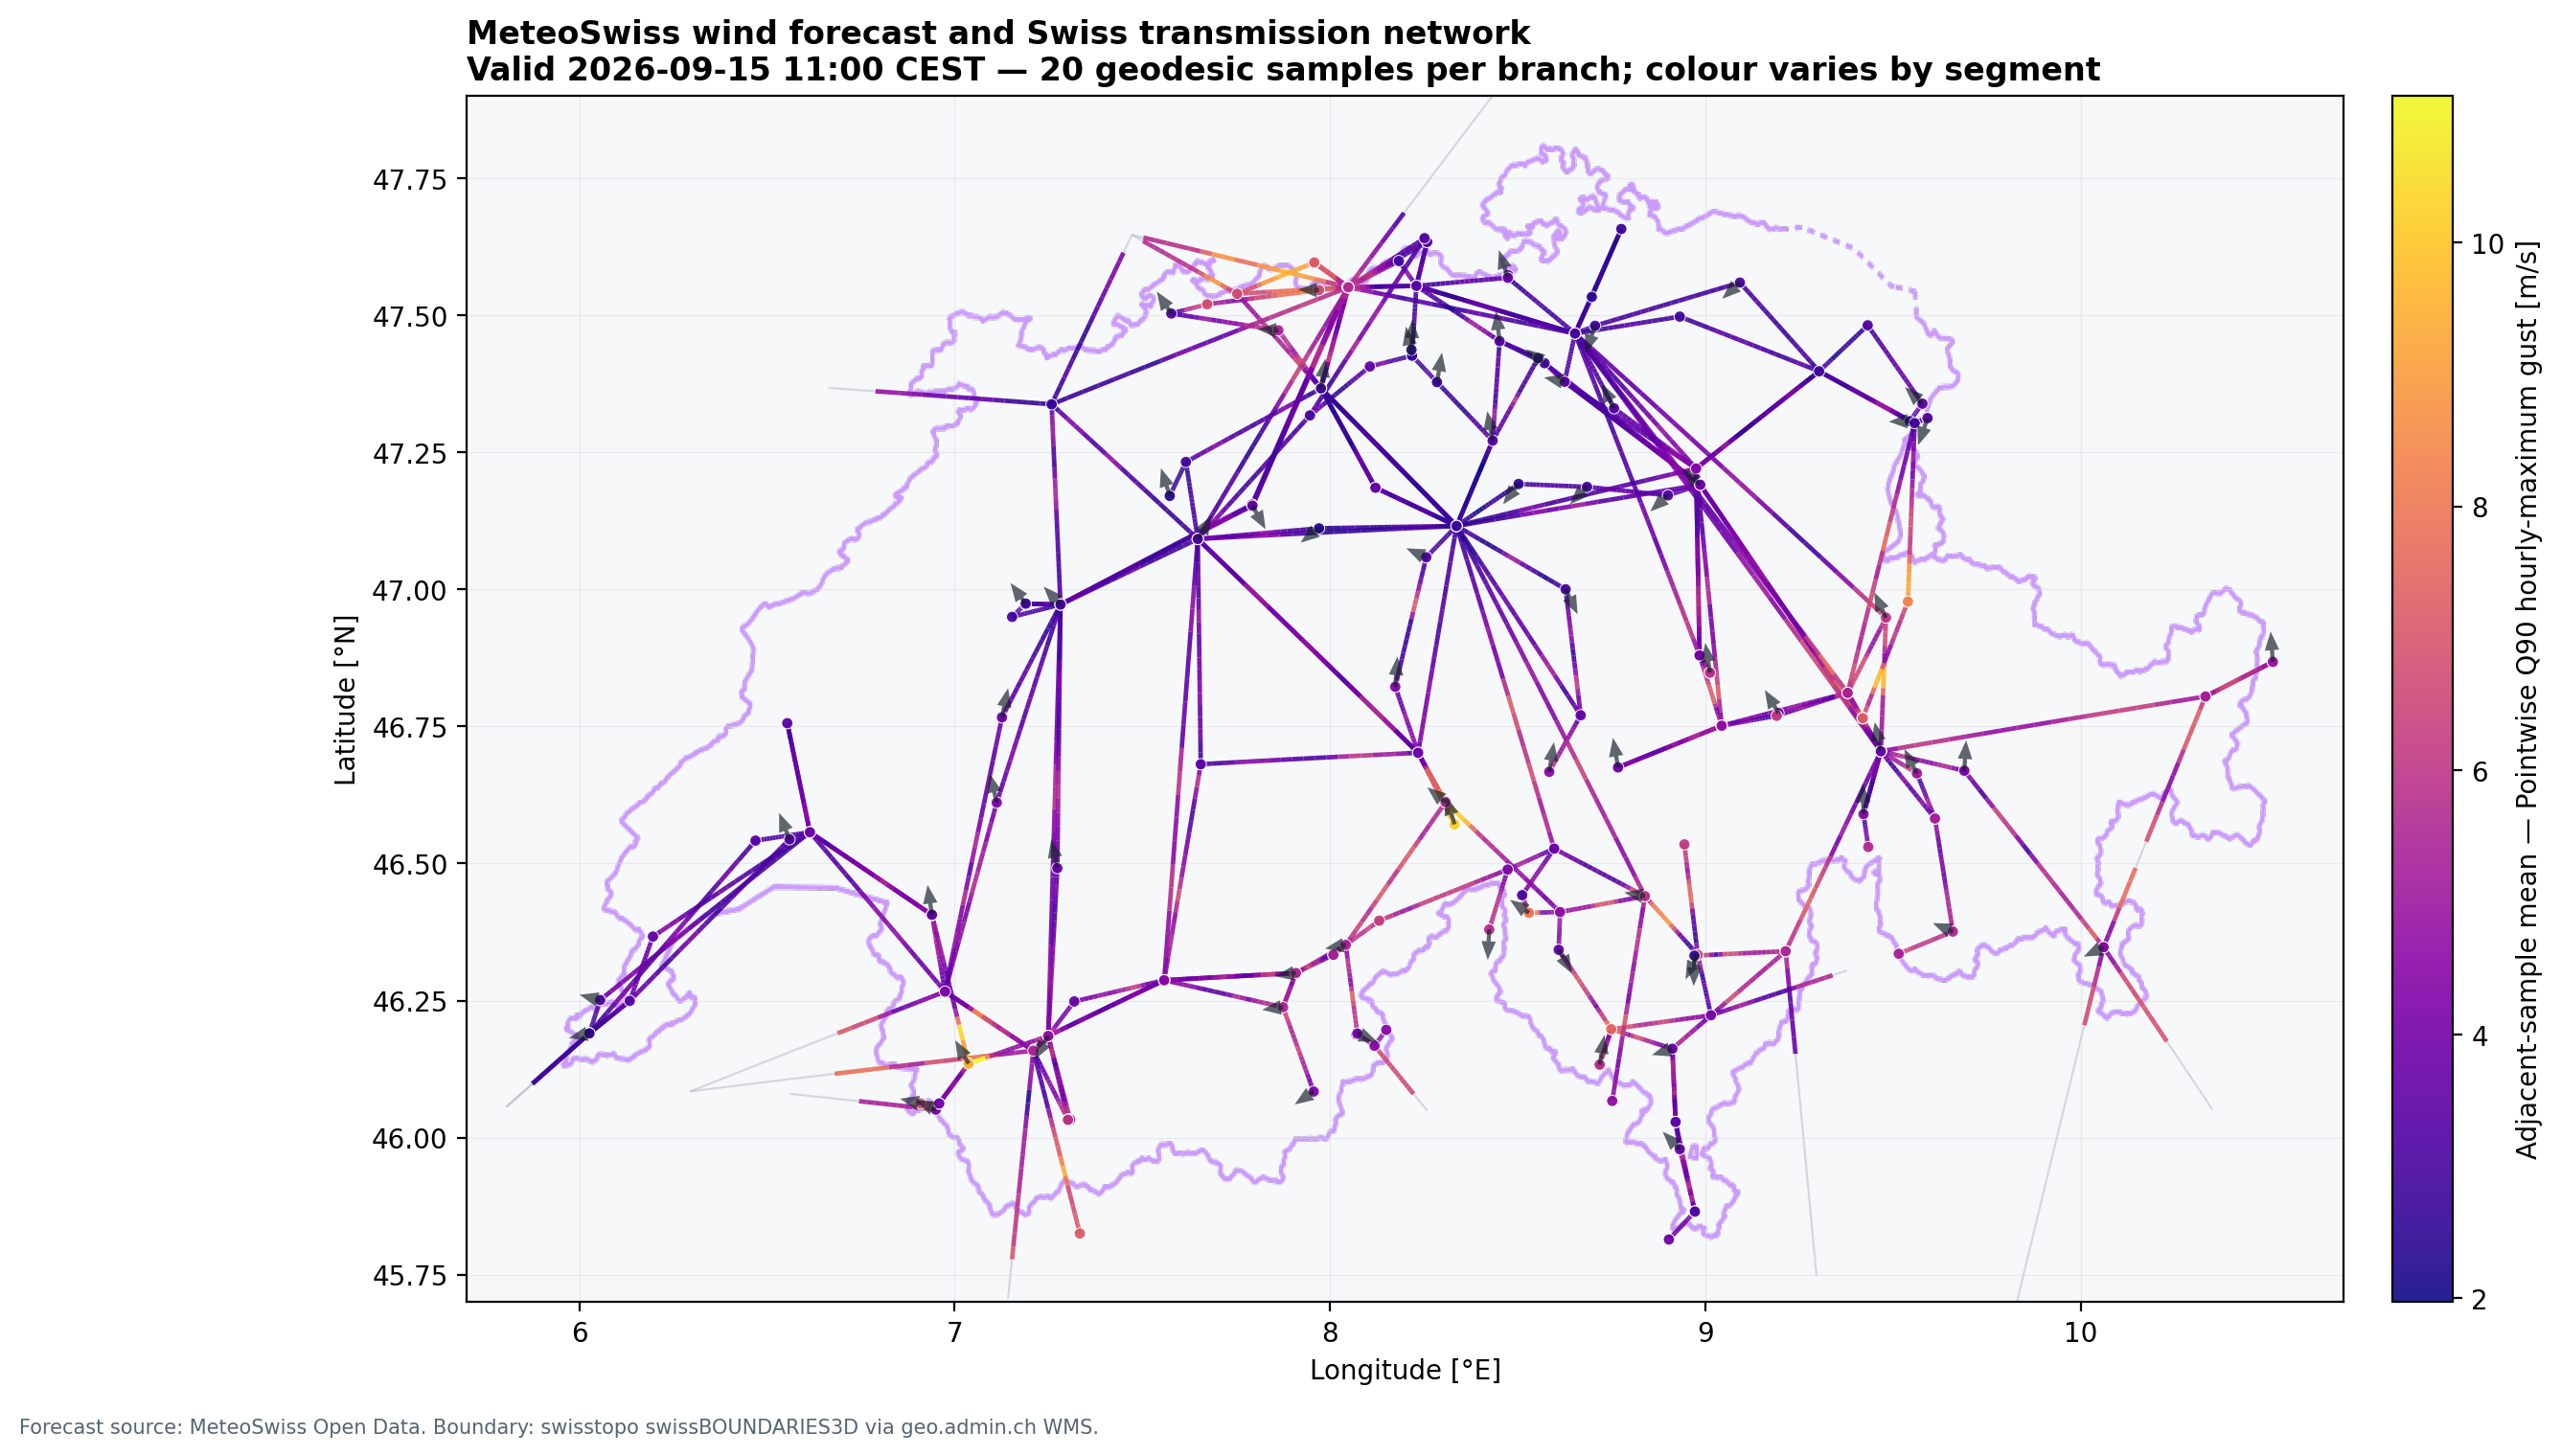

In [12]:
display(Image(filename=str(result["map_paths"]["png"])))


## Interpretation and limitations

- Branch-segment colour represents the mean of the two adjacent sampled values
  for the selected pointwise forecast statistic.
- `line_wind_quantile_summary.csv` contains mean and maximum Q10, main and Q90
  summaries over the 20 locations. A maximum of pointwise Q90 values is not the
  calibrated Q90 of the spatial maximum along the conductor.
- `wind_forecast_at_line_samples.csv` is the DataFrame-ready probabilistic
  summary. It contains quantiles, not a full PDF and not scenarios.
- The local forecasts are postprocessed forecasts at predefined points. A
  nearest-point match does not account for elevation differences.
- Samples follow the endpoint great-circle path because `branch.csv` has no
  conductor polyline. Replace this geometry with actual line routes when they
  become available.
- For coherent PRA scenarios, retrieve the ICON-CH1-EPS ensemble members rather
  than independently sampling the pointwise Q10/Q90 intervals.
- `branch.csv` does not distinguish overhead conductors from underground
  cables. Add an explicit asset classification before applying wind fragility
  models.

The equivalent command-line implementation is provided in
`meteoswiss_wind_forecast.py`.


In [13]:
PROJECT_ROOT

WindowsPath('C:/Users/roberto.rocchetta/Documents/GitHub/PROPER')

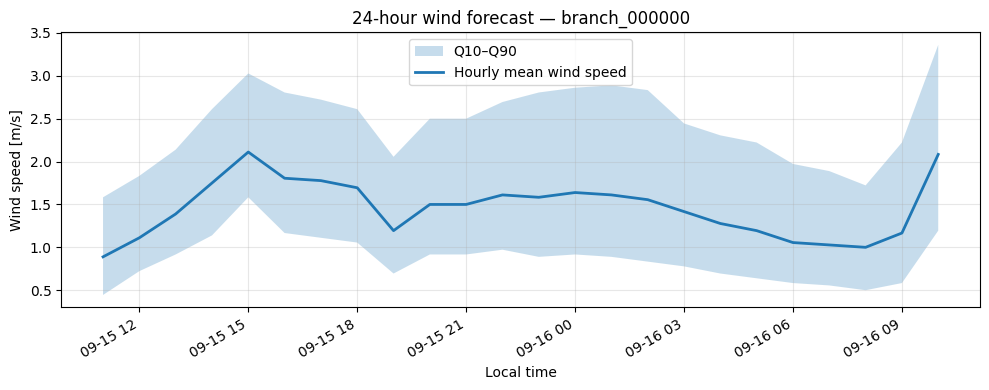

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

LINE_ID = "branch_000000"  # change this

df = result["line_point_wind"]
line = df[df["line_id"].astype(str).eq(str(LINE_ID))].copy()

mid_target = (
    line[["target_id", "sample_index", "sample_fraction"]]
    .drop_duplicates()
    .assign(distance=lambda x: (x["sample_fraction"] - 0.5).abs())
    .sort_values(["distance", "sample_index"])
    .iloc[0]["target_id"]
)

wind = (
    line[line["target_id"].eq(mid_target)]
    .loc[lambda x: x["forecast_lead_hours"].between(1, 24)]
    .sort_values("valid_time_utc")
    .copy()
)
wind["time"] = pd.to_datetime(
    wind["valid_time_utc"], utc=True
).dt.tz_convert("Europe/Zurich")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    wind["time"],
    wind["wind_speed_q10_ms"],
    wind["wind_speed_q90_ms"],
    alpha=0.25,
    label="Q10–Q90",
)
ax.plot(
    wind["time"],
    wind["wind_speed_ms"],
    linewidth=2,
    label="Hourly mean wind speed",
)
ax.set(title=f"24-hour wind forecast — {LINE_ID}",
       ylabel="Wind speed [m/s]", xlabel="Local time")
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

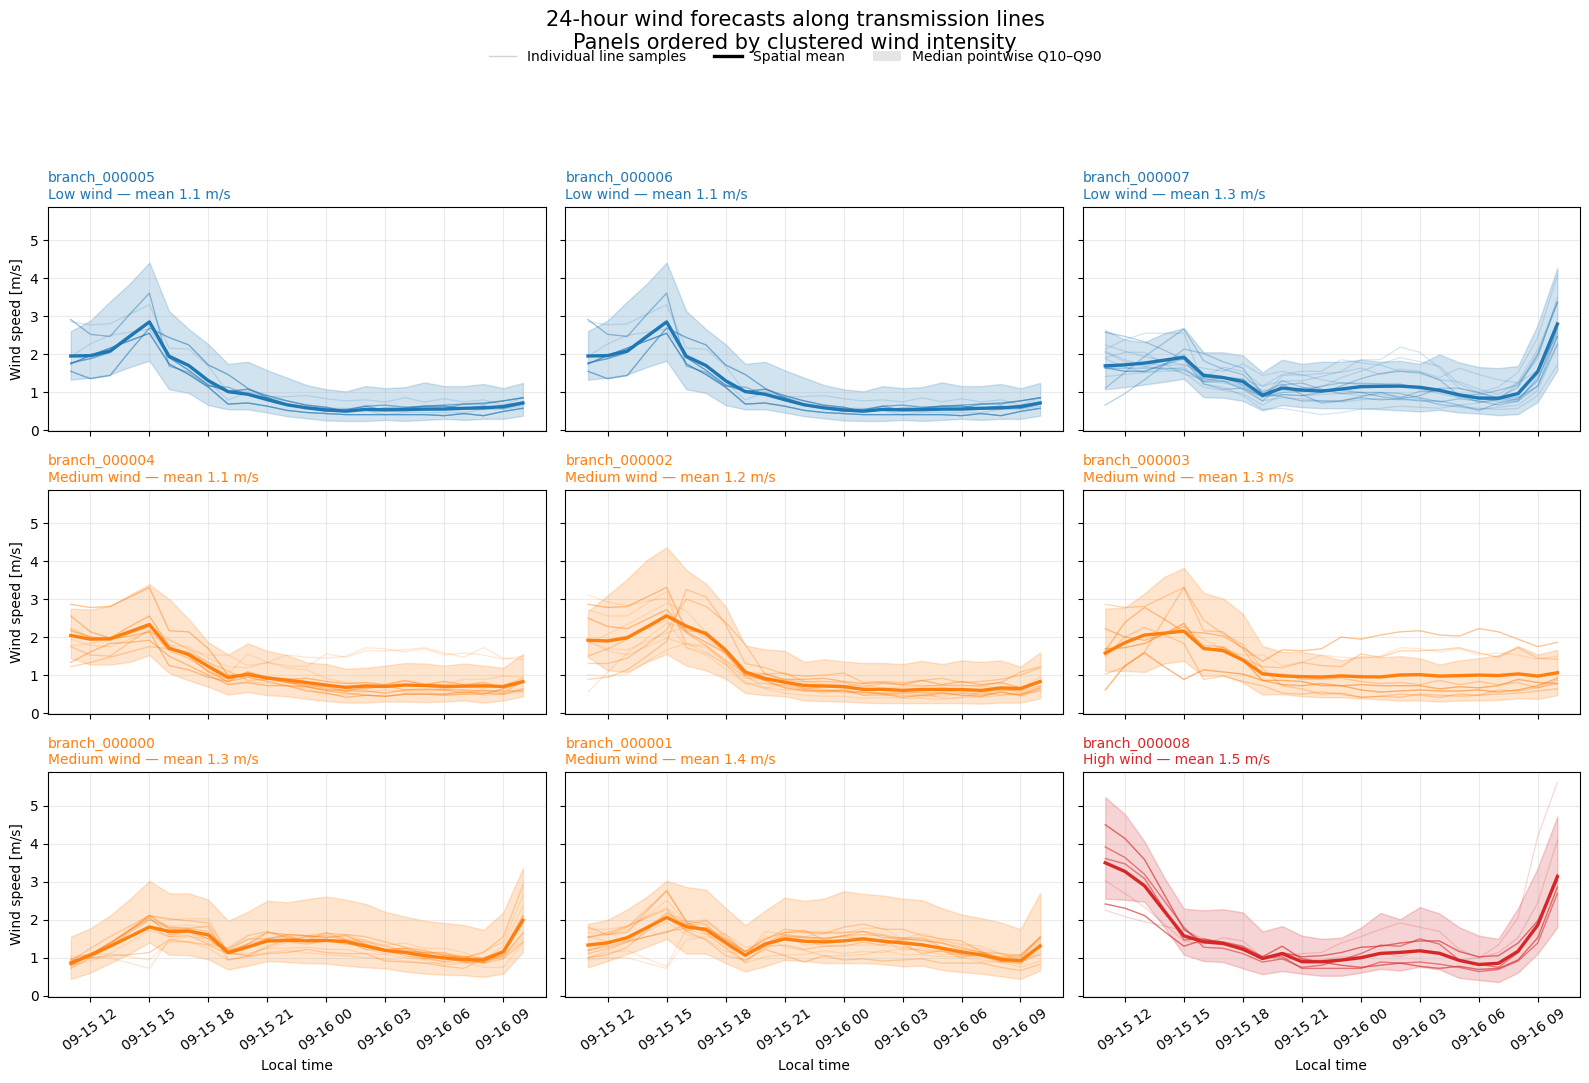

,wind_cluster,mean_speed,peak_speed,mean_q90
line_id,,,,
branch_000005,Low,1.11,3.61,1.91
branch_000006,Low,1.11,3.61,1.91
branch_000007,Low,1.33,4.08,2.23
branch_000004,Medium,1.14,3.31,2.02
branch_000002,Medium,1.17,3.31,2.18
branch_000003,Medium,1.26,3.31,2.38
branch_000000,Medium,1.33,2.92,2.27
branch_000001,Medium,1.40,2.78,2.38
branch_000008,High,1.53,5.61,2.45


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Correct names: branch_000000, ..., branch_000008
LINE_IDS = [f"branch_{k:06d}" for k in range(9)]

df = result["line_point_wind"].copy()
df["line_id"] = df["line_id"].astype(str)
df["time"] = ( pd.to_datetime(df["valid_time_utc"], utc=True).dt.tz_convert("Europe/Zurich"))

# Retain the first 24 forecast hours and the selected lines
plot_df = df.loc[df["line_id"].isin(LINE_IDS) & df["forecast_lead_hours"].between(1, 24)].copy()

missing = sorted(set(LINE_IDS) - set(plot_df["line_id"]))
if missing:
    raise ValueError(f"No wind data found for: {missing}")

# ------------------------------------------------------------------
# Cluster lines according to 24-hour wind intensity
# ------------------------------------------------------------------
line_features = (plot_df.groupby("line_id").agg(mean_speed=("wind_speed_ms", "mean"),
                                                peak_speed=("wind_speed_ms", "max"), mean_q90=("wind_speed_q90_ms", "mean"),) )
n_clusters = min(3, len(line_features))
kmeans = KMeans( n_clusters=n_clusters, random_state=42, n_init=20,)
line_features["cluster_raw"] = kmeans.fit_predict(    line_features[["mean_speed", "peak_speed", "mean_q90"]])

# Relabel clusters according to increasing average wind intensity
cluster_order = ( line_features.groupby("cluster_raw")["mean_speed"].mean().sort_values().index)
intensity_names = ["Low", "Medium", "High"][-n_clusters:]
cluster_name = { cluster: intensity_names[position] for position, cluster in enumerate(cluster_order) }
line_features["wind_cluster"] = ( line_features["cluster_raw"].map(cluster_name) )

# Order panels from low to high intensity
line_features["cluster_rank"] = ( line_features["cluster_raw"].map( {cluster: rank for rank, cluster in enumerate(cluster_order)}))
line_features = line_features.sort_values(    ["cluster_rank", "mean_speed"])
ordered_line_ids = line_features.index.tolist()
cluster_colours = {    "Low": "tab:blue",    "Medium": "tab:orange",    "High": "tab:red",}

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(    3,    3,    figsize=(16, 11),    sharex=True,    sharey=True,)
axes = axes.ravel()

for ax, line_id in zip(axes, ordered_line_ids):
    line = plot_df.loc[plot_df["line_id"].eq(line_id)].copy()

    cluster = line_features.loc[line_id, "wind_cluster"]
    colour = cluster_colours[cluster]

    # Superimpose the mean forecast at every sampled point
    for _, sample in line.groupby("target_id"):
        sample = sample.sort_values("time")

        ax.plot( sample["time"],
            sample["wind_speed_ms"],
            color=colour,
            linewidth=0.9,
            alpha=0.18,
        )

    # Spatial summary across the sampled points at each hour
    summary = (
        line.groupby("time", as_index=False)
        .agg(
            spatial_mean=("wind_speed_ms", "mean"),
            spatial_q10=("wind_speed_q10_ms", "median"),
            spatial_q90=("wind_speed_q90_ms", "median"),
        )
        .sort_values("time")
    )

    ax.fill_between(
        summary["time"],
        summary["spatial_q10"],
        summary["spatial_q90"],
        color=colour,
        alpha=0.20,
    )

    ax.plot(
        summary["time"],
        summary["spatial_mean"],
        color=colour,
        linewidth=2.4,
    )

    # Use branch endpoints when available
    if {"fbus", "tbus"}.issubset(line.columns):
        fbus = line["fbus"].iloc[0]
        tbus = line["tbus"].iloc[0]
        line_name = f"{line_id}: bus {fbus}–{tbus}"
    else:
        line_name = line_id

    mean_speed = line_features.loc[line_id, "mean_speed"]

    ax.set_title(
        f"{line_name}\n{cluster} wind — mean {mean_speed:.1f} m/s",
        loc="left",
        fontsize=10,
        color=colour,
    )
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=35)

# Hide unused panels, if fewer than nine lines are available
for ax in axes[len(ordered_line_ids):]:
    ax.set_visible(False)

for ax in axes[::3]:
    ax.set_ylabel("Wind speed [m/s]")

for ax in axes[-3:]:
    ax.set_xlabel("Local time")

legend_items = [
    Line2D(
        [0], [0],
        color="grey",
        alpha=0.35,
        linewidth=1,
        label="Individual line samples",
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=2.4,
        label="Spatial mean",
    ),
    Patch(
        facecolor="grey",
        alpha=0.20,
        label="Median pointwise Q10–Q90",
    ),
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=3,
    frameon=False,
)

fig.suptitle(
    "24-hour wind forecasts along transmission lines\n"
    "Panels ordered by clustered wind intensity",
    fontsize=15,
)

fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

display(
    line_features[
        ["wind_cluster", "mean_speed", "peak_speed", "mean_q90"]
    ].round(2)
)